In questo esercizio si stima la distribuzione a posteriori di omega_m usando una catena MCMC con algoritmo Metropolis-Hastings. Dopo aver generato la catena, si calcola la media e si analizza l’autocorrelazione per stimare quanto i campioni siano indipendenti. Infine, si confronta il comportamento della catena reale con una non correlata per evidenziare gli effetti della dipendenza tra punti.

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm.notebook import tqdm     # Barra di avanzamento per loop

In [2]:
omegam, chi2 = np.load("chi2_values.npy")
posterior = np.exp(-0.5 * chi2)
interp_chi2 = interp1d(omegam, -0.5*chi2, kind='cubic')  # Interpolazione chi^2

In [3]:
def MCMC(x0, n_steps, x_min, x_max):  # Funzione MCMC base con algoritmo Metropolis-Hastings
    chain = [] 
    accepted = [] 
    chi2_chain = [] 

    chain.append(x0)  # Inizializza la catena con il valore iniziale
    accepted.append(True) # Indica che il primo valore è accettato
    chi2_chain.append(interp_chi2(x0)) # Calcola il chi^2 iniziale

    for i in tqdm(range(n_steps)): # ciclo for che esegue n_steps iterazioni
        x_try = np.random.uniform(x_min, x_max)  # Prova un nuovo valore casuale
        f_try = interp_chi2(x_try)  # Calcola il chi^2 per il nuovo valore
        f_old = interp_chi2(chain[-1])  # Calcola il chi^2 per l'ultimo valore accettato
        log_ratio = f_try - f_old  # Log del rapporto tra le due posterior
        log_u = np.log(np.random.uniform())  # Genera un numero casuale uniforme e calcola il logaritmo

        if log_u < log_ratio: # Accetta il nuovo valore se il logaritmo del numero casuale è minore del logaritmo del rapporto
            chain.append(x_try)
            accepted.append(True)
            chi2_chain.append(f_try)
        else:     # Altrimenti, rifiuta il nuovo valore e mantiene l'ultimo accettato
            chain.append(chain[-1]) 
            accepted.append(False)
            chi2_chain.append(f_old)
    
    return chain, chi2_chain, accepted 

<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_101208/3813494614.py:13: SyntaxWarning: invalid escape sequence '\O'
  plt.title("MCMC Chain for $\Omega_m$")


  0%|          | 0/10000 [00:00<?, ?it/s]

Acceptance rate:  0.198980101989801


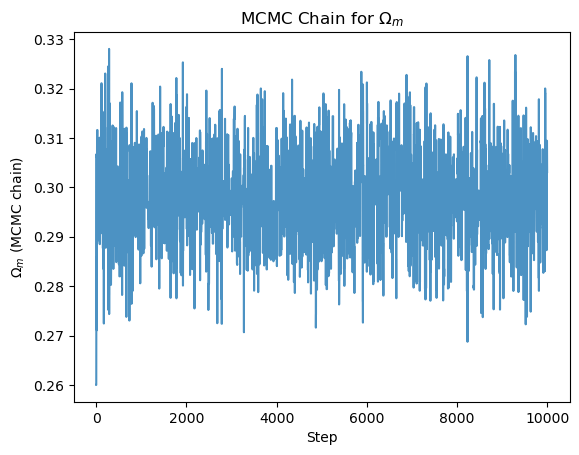

In [4]:
x_min = 0.23   # Estremo inferiore intervallo prior
x_max = 0.37   # Estremo superiore intervallo prior
n_steps = 10000  # Numero di passi della catena MCMC
x0 = 0.26    # Valore iniziale della catena

chain, chi2_chain, accepted = MCMC(x0, n_steps, x_min, x_max)  # Esecuzione della funzione MCMC

print("Acceptance rate: ", np.sum(accepted) / len(accepted))

plt.plot(chain, alpha=0.8)
plt.xlabel("Step")
plt.ylabel(r"$\Omega_m$ (MCMC chain)")
plt.title("MCMC Chain for $\Omega_m$")
plt.show()

NB: La catena oscilla intorno a un valore centrale, segno che la MCMC ha trovato una zona di buona probabilità (intorno a omega_m=0.30) e ci resta.

In [5]:
print("Omega_m: ", np.mean(chain[:1000]), "+/-", np.std(chain[:1000]))

Omega_m:  0.2991566763146277 +/- 0.009306783864827603


Voglio verificare quanto i punti siano indipendenti tra loro e calcolare il tempo di autocorrelazione della catena MCMC.
NB: L’autocorrelazione di una sequenza può essere calcolata in modo diretto, ma il metodo "a mano" ha costo computazionale O(N^2), mentre la FFT permette di calcolarla in O(N log N), ovvero è molto più veloce su lunghe catene (come quella considerata).
Inoltre gli algoritmi di FFT lavorano internamente su blocchi binari, quindi se l’array ha una lunghezza che è già una potenza di 2 la FFT è molto veloce e stabile.

In [6]:
# Funzione che restituisce la potenza di 2 più vicina a n
def next_pow_two(n): 
    i = 1 # Inizializza i a 1
    while i < n:  # Ciclo che continua finché i è minore di n
        i = i << 1 # Sposta i a sinistra di 1 bit (equivalente a moltiplicare per 2)
    return i   

# Funzione per calcolare la funzione di autocorrelazione 1D, ovvero quanto ogni punto è correlato con i suoi vicini a distanza crescente
def autocorr_func_1d(x, norm=True):  
    x = np.atleast_1d(x)  # Assicura che x sia almeno un array 1D
    if len(x.shape) != 1:  
        raise ValueError("invalid dimensions for 1D autocorrelation function")
    n = next_pow_two(len(x)) # Trova la potenza di 2 più vicina alla lunghezza di x, per ottimizzare la FFT

    f = np.fft.fft(x - np.mean(x), n=2 * n) # Trasformata di Fourier, sottndo la media per centrare i datirae
    acf = np.fft.ifft(f * np.conjugate(f))[: len(x)].real # Calcola l'autocorrelazione con la trasformata inversa di Fourier, prendendo solo la parte reale

    acf /= 4 * n # Normalizza l'autocorrelazione per la lunghezza della serie e il numero di punti
    if norm:    # Se richiesto, normalizza l'autocorrelazione
        acf /= acf[0] 

    return acf 

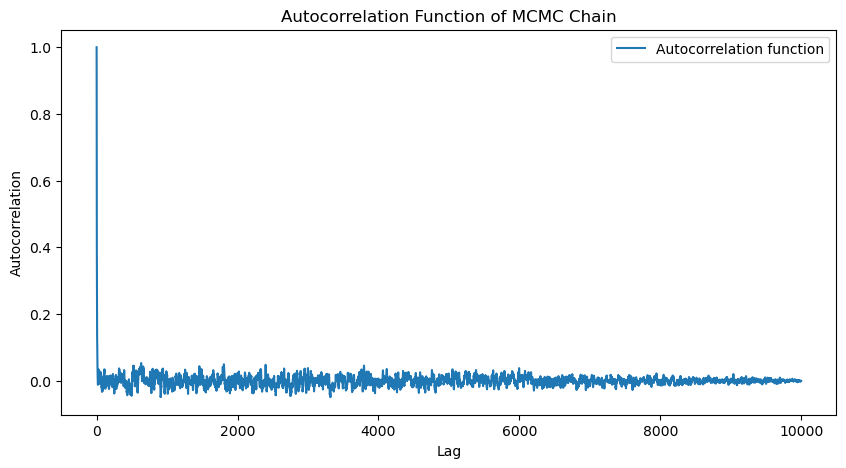

In [7]:
steps = [10, 20, 50, 100] # Diversi ritardi per stimare il tempo di autocorrelazione
autocorrelation_time = [] 

for step in steps:
    acf = autocorr_func_1d(chain, norm=True) # Calcola l'autocorrelazione della catena MCMC
    tau = 0.5 + np.sum(acf[1:step]) / acf[0]  # Calcola il tempo di autocorrelazione come la somma dei valori di autocorrelazione fino al ritardo specificato, normalizzato dal primo valore di autocorrelazione
    autocorrelation_time.append(tau) 

plt.figure(figsize=(10, 5))
plt.plot(acf, label="Autocorrelation function")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function of MCMC Chain")
plt.legend()
plt.show()

NB: Nel grafico l’autocorrelazione inizia da 1, perché ogni punto è ovviamente perfettamente correlato con sé stesso. Subito dopo però, invece di crollare a zero (come farebbe una sequenza di numeri indipendenti), l’autocorrelazione scende gradualmente. Questo ci dice che i punti della catena MCMC sono correlati tra loro: ogni nuovo valore è generato a partire da quello precedente, quindi conserva un po’ di memoria, che ha senso dato che il metodo MCMC costruisce la catena passo dopo passo.

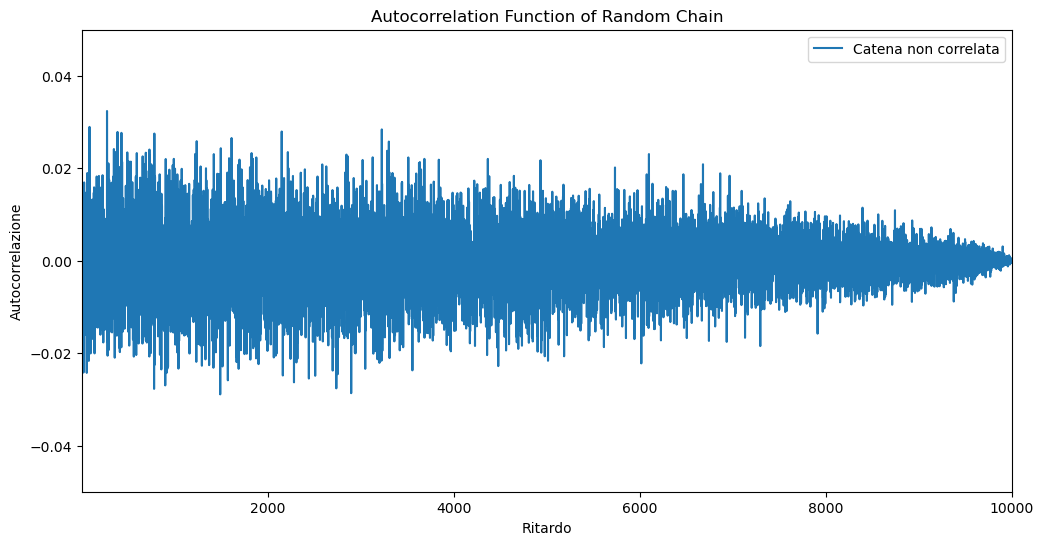

In [8]:

# Catena "ideale", non correlata, con stessa media e deviazione standard
np.random.seed(42)  # Imposta il seed per la riproducibilità
chain_random = np.random.normal(loc=np.mean(chain), scale=np.std(chain), size=len(chain))

acf_random = autocorr_func_1d(chain_random)

plt.figure(figsize=(12, 6))
plt.plot(acf_random, label="Catena non correlata")
plt.xlim(2, 10000)
plt.ylim(-0.05, 0.05)
plt.xlabel("Ritardo")  # =di quanti passi viene “spostata” la catena per confrontarla con sé stessa.
plt.ylabel("Autocorrelazione") # quanto i valori della catena sono correlati con quelli a distanza lag
plt.title("Autocorrelation Function of Random Chain")
plt.legend()
plt.show()

NB: Questo grafico mostra la funzione di autocorrelazione di una catena casuale non correlata, ovvero una sequenza di numeri estratti in modo indipendente da una distribuzione normale. I piccoli picchi positivi e negativi sono rumore statistico, dovuto al fatto che la catena è finita in lunghezza, ma non indicano vera correlazione